In [1]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister

In [ ]:
NUM_RUNS = 5
SHOTS_PER_RUN = 1024
OPT_LEVEL = 3
SEED_TRANSPILER = 42

In [8]:
from qiskit.circuit.library import QFT

N = 771
n_bits = N.bit_length()
A=2

r = 16 # used only to calculate Hellinger Fidelity

x_bits = 2*n_bits
x_bits_on_circuit = 5 # used to control qft / reg_x size on the circuit, needs to be at least 1 bigger than the number of non identity multiplications for it to be discenrnible from noise

reg_x = QuantumRegister(x_bits_on_circuit, "x_reg")
reg_b = QuantumRegister(n_bits, "b_reg") 
reg_result = ClassicalRegister(x_bits_on_circuit, "result")

qc = QuantumCircuit(reg_x, reg_b, reg_result)


qc.h(reg_x)
qc.x(reg_b[0])
qc.barrier()

l = [pow(A, 2**k, N) for k in range(2*N.bit_length())]
z = len(l) - l.count(1)

for i in range(z):

        if i==0 and A**(2**(i)) % N == 2:
            qc.cx(reg_x[0], reg_b[0])
            qc.cx(reg_x[0], reg_b[1])
            qc.barrier()

        elif i==1 and A**(2**(i)) % N == 4:
            qc.cswap(reg_x[1], reg_b[0], reg_b[2])
            qc.cswap(reg_x[1], reg_b[1], reg_b[3])
            qc.barrier()

        elif i == 2:
            qc.cswap(reg_x[2], reg_b[0], reg_b[4])
            qc.cswap(reg_x[2], reg_b[1], reg_b[5])
            qc.cswap(reg_x[2], reg_b[2], reg_b[6])
            qc.cswap(reg_x[2], reg_b[3], reg_b[7])
            qc.barrier()
        elif i == 3:
            qc.cswap(reg_x[3], reg_b[0], reg_b[8])
            qc.cswap(reg_x[3], reg_b[1], reg_b[9])
            
            qc.mcx(reg_x[:z], reg_b[0], ctrl_state=bin(10)[2:].zfill(z))
            qc.mcx(reg_x[:z], reg_b[3], ctrl_state=bin(10)[2:].zfill(z))

            qc.mcx(reg_x[:z], reg_b[1], ctrl_state=bin(11)[2:].zfill(z))
            qc.mcx(reg_x[:z], reg_b[8], ctrl_state=bin(11)[2:].zfill(z))

            qc.mcx(reg_x[1:z], reg_b[4], ctrl_state=bin(5)[2:].zfill(z-1))
            qc.mcx(reg_x[1:z], reg_b[5], ctrl_state=bin(5)[2:].zfill(z-1))
            qc.mcx(reg_x[1:z], reg_b[6], ctrl_state=bin(5)[2:].zfill(z-1))
            qc.mcx(reg_x[1:z], reg_b[7], ctrl_state=bin(5)[2:].zfill(z-1))

            qc.mcx(reg_x[0:1]+reg_x[2:z], reg_b[0], ctrl_state=bin(6)[2:].zfill(z-1))

            qc.mcx(reg_x[1:z], reg_b[6], ctrl_state=bin(6)[2:].zfill(z-1))
            qc.mcx(reg_x[1:z], reg_b[7], ctrl_state=bin(6)[2:].zfill(z-1))

            qc.mcx(reg_x[0:1]+reg_x[2:z], reg_b[1], ctrl_state=bin(7)[2:].zfill(z-1))
            qc.mcx(reg_x[0:1]+reg_x[2:z], reg_b[8], ctrl_state=bin(7)[2:].zfill(z-1))

            qc.mcx(reg_x[:z], reg_b[5], ctrl_state=bin(12)[2:].zfill(z))

            qc.mcx(reg_x[:z], reg_b[7], ctrl_state=bin(14)[2:].zfill(z))

qc.append(QFT(x_bits_on_circuit).inverse(), reg_x[:])

qc.measure(reg_x[:], reg_result)

C:\Users\guida\AppData\Local\Temp\ipykernel_11672\27951800.py:71: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  qc.append(QFT(x_bits_on_circuit).inverse(), reg_x[:])


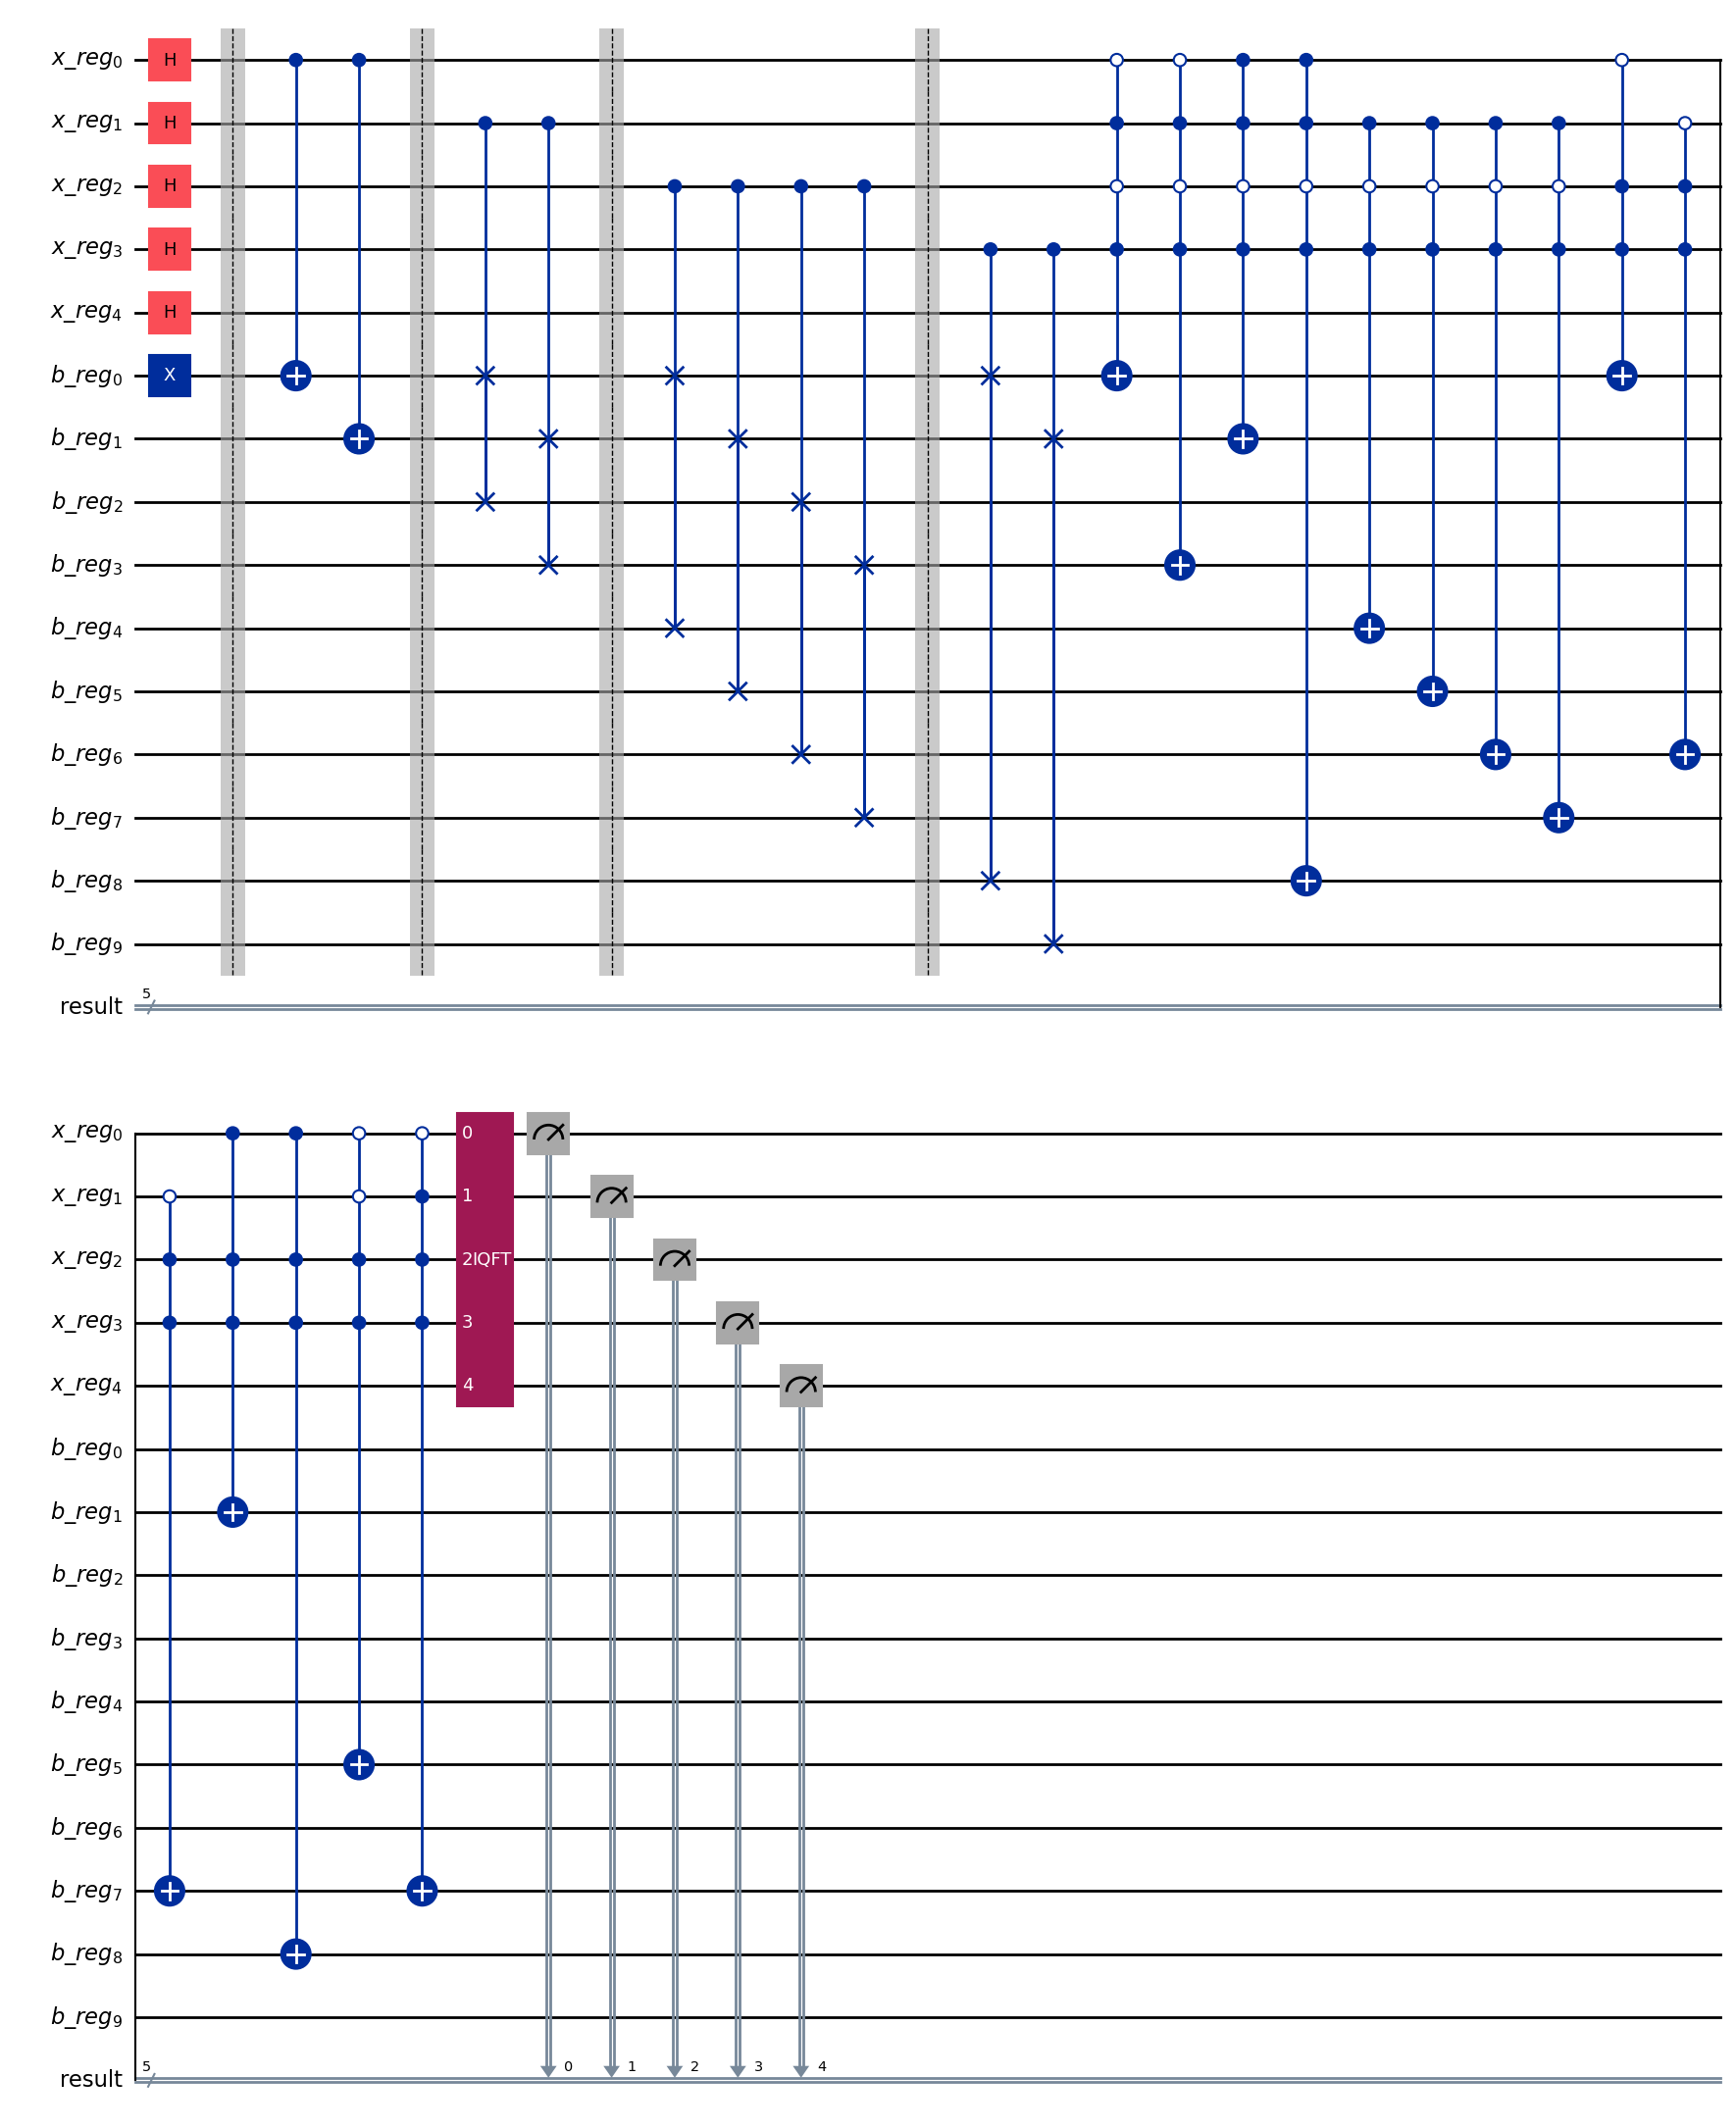

In [3]:
qc.draw("mpl")

In [ ]:
from qiskit import transpile
from qiskit_ibm_runtime import QiskitRuntimeService
import os
from dotenv import load_dotenv

load_dotenv()

api_token = os.getenv("IBM_QUANTUM_TOKEN")


service = QiskitRuntimeService(channel="ibm_cloud", token=api_token)
backend = service.backend(name='ibm_marrakesh')

transpiled_circuit = transpile(
    qc, 
    backend=backend, 
    optimization_level=OPT_LEVEL, 
    seed_transpiler=SEED_TRANSPILER
)

print(f"Circuit hardware depth: {transpiled_circuit.depth()}")
print(f"Gate count: {transpiled_circuit.count_ops()}")

qiskit_runtime_service._discover_account:WARNING:2026-05-06 23:11:29,355: Loading account with the given token. A saved account will not be used.
qiskit_runtime_service.__init__:WARNING:2026-05-06 23:11:33,414: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2026-05-06 23:11:33,415: Using instance: open-instance, plan: open


Circuit hardware depth: 2203
Gate count: OrderedDict({'sx': 1893, 'rz': 927, 'cz': 903, 'x': 16, 'measure': 5, 'barrier': 4})


In [ ]:
import numpy as np
from qiskit_ibm_runtime import SamplerV2 as Sampler


results_list = []
job_ids = []

backend_props = backend.properties()
print(f"Executing on backend: {backend.name} , {backend_props.last_update_date}")

sampler = Sampler(mode=backend)

for i in range(NUM_RUNS):
    print(f"Initializing round {i+1}/{NUM_RUNS}...")

    job = sampler.run(pubs=[transpiled_circuit], shots=SHOTS_PER_RUN)
    j_id = job.job_id()
    job_ids.append(j_id)
    result = job.result()
    counts = result[0].data.result.get_int_counts()
    results_list.append(counts)

total_counts = {}
for run_counts in results_list:
    for key, val in run_counts.items():
        total_counts[key] = total_counts.get(key, 0) + val

avg_probs = {k: v / (NUM_RUNS * SHOTS_PER_RUN) for k, v in total_counts.items()}

Executing on backend: ibm_marrakesh , 2026-05-06 22:54:43-03:00
Initializing round 1/5...
Initializing round 2/5...
Initializing round 3/5...
Initializing round 4/5...
Initializing round 5/5...


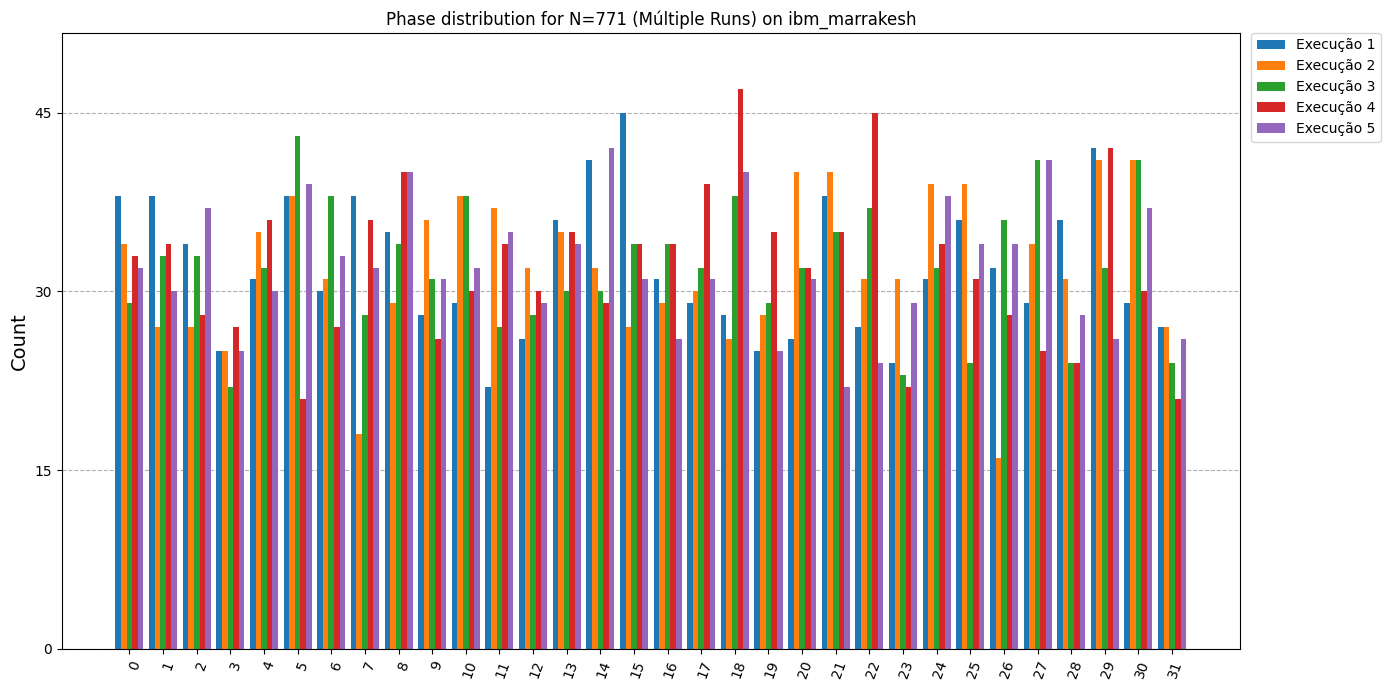

In [ ]:
from qiskit.visualization import plot_histogram

results_to_plot = []
run_labels = []

for index, j_id in enumerate(job_ids):
    job = service.job(j_id)
    result = job.result()
    
    counts = result[0].data.result.get_int_counts()
    
    results_to_plot.append(counts)
    run_labels.append(f"Run {index + 1}")

plot_histogram(
    results_to_plot, 
    legend=run_labels, 
    title=f"Phase distribution for N={N} (Multiple Runs) on {backend.name}",
    figsize=(14, 7),
    bar_labels=False
)

In [ ]:
import json
import numpy as np
from datetime import datetime
from fractions import Fraction
from qiskit.quantum_info import hellinger_fidelity

def calculate_ideal_probs(order_r, qft_bits):
    q = 2 ** qft_bits
    probability_per_peak = 1.0 / order_r
    peak_distance = q // order_r
    
    ideal_probs = {}
    for k in range(order_r):
        expected_state = k * peak_distance
        ideal_probs[int(expected_state)] = probability_per_peak
        
    return ideal_probs

def analyze_shor_success(counts, qft_bits, N_modulus, expected_r, ideal_peaks):
    q = 2 ** qft_bits
    success_shots = 0
    shots_on_ideal_peaks = 0
    total_shots = sum(counts.values())
    successful_states = set()
    
    for state_str, count in counts.items():
        s = int(state_str)
        
        is_ideal_peak = s in ideal_peaks
        if is_ideal_peak:
            shots_on_ideal_peaks += count

        if s == 0:
            continue
            
        fraction = Fraction(s, q).limit_denominator(N_modulus)
        candidate_r = fraction.denominator
        
        if candidate_r == expected_r:
            success_shots += count
            successful_states.add(s)
            
    total_success_rate = success_shots / total_shots if total_shots > 0 else 0
    peak_success_rate = success_shots / shots_on_ideal_peaks if shots_on_ideal_peaks > 0 else 0
    
    return total_success_rate, peak_success_rate, sorted(list(successful_states))

ideal_probs = calculate_ideal_probs(r, x_bits_on_circuit)
ideal_peaks = set(ideal_probs.keys())
ideal_qft_size = x_bits 

fidelities = []
total_success_rates = []
peak_success_rates = []
all_successful_peaks = set()
shots_used = SHOTS_PER_RUN

for run_counts in results_list:
    run_probs = {int(k): v / shots_used for k, v in run_counts.items()}
    f = hellinger_fidelity(run_probs, ideal_probs)
    fidelities.append(f)
    
    t_rate, p_rate, s_peaks = analyze_shor_success(run_counts, x_bits_on_circuit, N, r, ideal_peaks)
    total_success_rates.append(t_rate)
    peak_success_rates.append(p_rate)
    all_successful_peaks.update(s_peaks)

mean_f = np.mean(fidelities)
std_f = np.std(fidelities)
mean_total_success = np.mean(total_success_rates)
std_total_success = np.std(total_success_rates)
mean_peak_success = np.mean(peak_success_rates)
std_peak_success = np.std(peak_success_rates)

filename = f"execs_{N}.txt"
timestamp = datetime.now().strftime("%Y-%m-%d %H:%M:%S")

print(f"Calculated! Mean Fidelity: {mean_f:.4f} +/- {std_f:.4f}")
print(f"Total Success Rate: {mean_total_success*100:.2f}%")
print(f"Peak Success Rate: {mean_peak_success*100:.2f}%")
print(f"Appending results to file: {filename}...")

with open(filename, "a") as file:
    file.write(f"=======================================================\n")
    file.write(f"[{timestamp}] EXECUTION BATCH - N = {N}\n")
    file.write(f"=======================================================\n\n")
    
    file.write("=== Algorithm and Circuit ===\n")
    file.write(f"Order (r) = {r}\n")
    file.write(f"Executed QFT Bits (x_bits_on_circuit) = {x_bits_on_circuit}\n")
    file.write(f"Ideal QFT Bits (ideal_qft_size) = {ideal_qft_size}\n")
    file.write(f"Transpiler Optimization Level = {OPT_LEVEL}\n")
    file.write(f"Transpiler Seed = {SEED_TRANSPILER}\n")
    file.write(f"Transpiled Depth = {transpiled_circuit.depth()}\n")
    
    gate_counts = dict(transpiled_circuit.count_ops())
    total_gates = sum(gate_counts.values())
    file.write(f"Total Gates = {total_gates}\n")
    file.write(f"Gate Types Breakdown = {json.dumps(gate_counts)}\n\n")
    
    file.write("=== Hardware and Execution ===\n")
    file.write(f"Backend = {backend.name}\n")
    file.write(f"Number of Runs = {NUM_RUNS}\n")
    file.write(f"Shots per Run = {shots_used}\n")
    
    try:
        props = backend.properties()
        calibration_date = props.last_update_date.strftime("%Y-%m-%d %H:%M:%S")
        file.write(f"Backend Calibration Date = {calibration_date}\n")
    except Exception:
        file.write(f"Backend Calibration Date = Unavailable\n")
        
    file.write("\n=== Statistical & Post-Processing Results ===\n")
    file.write(f"Hellinger Fidelity = {mean_f:.4f} +/- {std_f:.4f}\n")
    file.write(f"Total Success Rate = {mean_total_success*100:.2f}% +/- {std_total_success*100:.2f}%\n")
    file.write(f"Expected Peak Success Rate = {mean_peak_success*100:.2f}% +/- {std_peak_success*100:.2f}%\n")
    file.write(f"Peaks yielding exact 'r' = {sorted(list(all_successful_peaks))}\n\n")
    
    file.write("=== Counts Distribution (Raw Data) ===\n")
    for i, counts in enumerate(results_list):
        counts_str = json.dumps(counts)
        file.write(f"Run {i+1} [Total Success: {total_success_rates[i]*100:.1f}% | Expected Peak Accuracy: {peak_success_rates[i]*100:.1f}%]: {counts_str}\n")
        
    file.write("\n\n") 

print("Recording completed successfully!")

Calculated! Mean Fidelity: 0.5066 +/- 0.0124
Mean Success Rate: 25.90% +/- 1.76%
Appending results to file: execs_771.txt...
Recording completed successfully!
